STEP 1: Loading & Splitting Dataset...
 - Data Loaded. Train Shape: (455, 30) | Test Shape: (114, 30)

STEP 2: Benchmarking Models...
 ✅ Logistic Regression Completed. (Test Acc: 0.9825)
 ✅ Decision Tree Completed. (Test Acc: 0.9123)
 ✅ Random Forest Completed. (Test Acc: 0.9561)
 ✅ SVM (Linear) Completed. (Test Acc: 0.9737)
 ✅ KNN (k=5) Completed. (Test Acc: 0.9561)

--- Final Results Table ---
              Model  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score  Time (s)      Status
Logistic Regression        0.989011       0.982456   0.986111 0.986111  0.986111  0.073743    Good Fit
       SVM (Linear)        0.991209       0.973684   0.985915 0.972222  0.979021  0.041532    Good Fit
      Random Forest        1.000000       0.956140   0.958904 0.972222  0.965517  0.434878    Good Fit
          KNN (k=5)        0.973626       0.956140   0.958904 0.972222  0.965517  0.016636    Good Fit
      Decision Tree        1.000000       0.912281   0.955882 0.902778  0.928571  0.02

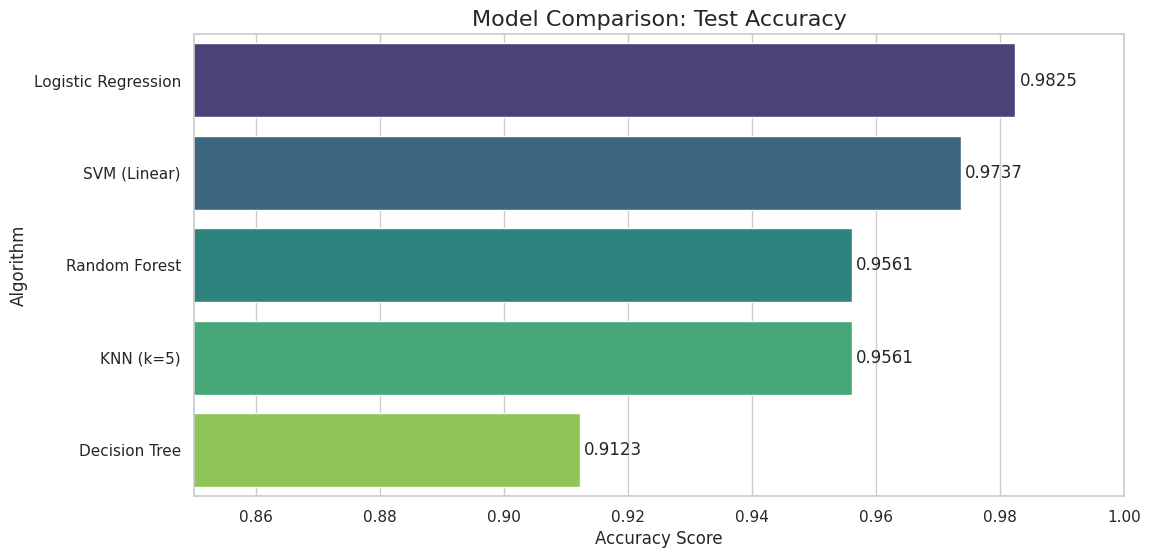


STEP 4: Selecting Best Model...
 🏆 WINNER: Logistic Regression
    - Recall: 0.9861
    - Accuracy: 0.9825
 💾 Model saved successfully as 'best_model_pipeline.pkl'


In [3]:
#  Model Comparison & Best Model Selection
# Dataset: Scikit-Learn Breast Cancer Wisconsin (Diagnostic)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Preprocessing & Evaluation
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# SETTING PROFESSIONAL VISUALIZATION THEME
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 8)

def load_and_split_data():
    """
    Loads dataset and splits it.
    We use the same split for ALL models to ensure fair comparison.
    """
    print("STEP 1: Loading & Splitting Dataset...")
    data = load_breast_cancer()
    X = data.data
    y = data.target

    # 80/20 Split with Stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Scaling is crucial for SVM, KNN, and Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f" - Data Loaded. Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

def get_models():
    """
    Defines the dictionary of models to benchmark.
    """
    models = {
        "Logistic Regression": LogisticRegression(random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "SVM (Linear)": SVC(kernel='linear', probability=True, random_state=42),
        "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
    }
    return models

def evaluate_models(models, X_train, X_test, y_train, y_test):
    """
    Loops through models, trains them, and logs performance metrics.
    """
    print("\nSTEP 2: Benchmarking Models...")

    results = []

    for name, model in models.items():
        start_time = time.time()

        # Train
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Metrics
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        precision = precision_score(y_test, y_test_pred)
        recall = recall_score(y_test, y_test_pred)
        f1 = f1_score(y_test, y_test_pred)

        elapsed = time.time() - start_time

        # Overfitting Check
        # If Train Acc >> Test Acc (e.g., > 5% gap), it's overfitting
        overfit_gap = train_acc - test_acc
        status = "Overfitting" if overfit_gap > 0.05 else "Good Fit"

        results.append({
            "Model": name,
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "Time (s)": elapsed,
            "Status": status
        })

        print(f" ✅ {name} Completed. (Test Acc: {test_acc:.4f})")

    return pd.DataFrame(results)

def visualize_comparison(df_results):
    """
    Plots a bar chart comparing models by Test Accuracy.
    """
    print("\nSTEP 3: Visualizing Leaderboard...")

    # Sort results for better visualization
    df_sorted = df_results.sort_values("Test Accuracy", ascending=False)

    plt.figure(figsize=(12, 6))

    # FIXED: Added hue=y to avoid FutureWarning
    ax = sns.barplot(
        x="Test Accuracy",
        y="Model",
        data=df_sorted,
        palette="viridis",
        hue="Model",      # Fix for Seaborn warning
        legend=False      # Hide legend since labels are on Y-axis
    )

    plt.xlim(0.85, 1.0) # Zoom in on the high scores to see differences
    plt.title("Model Comparison: Test Accuracy", fontsize=16)
    plt.xlabel("Accuracy Score")
    plt.ylabel("Algorithm")

    # Add labels to bars
    for i in ax.containers:
        ax.bar_label(i, fmt='%.4f', padding=3)

    plt.show()

def select_and_save_best(df_results, models, scaler):
    """
    Selects the best model based on Recall (crucial for Cancer detection)
    and saves it.
    """
    print("\nSTEP 4: Selecting Best Model...")

    # Sort by Recall first (safety), then Accuracy (performance)
    best_row = df_results.sort_values(by=["Recall", "Test Accuracy"], ascending=False).iloc[0]
    best_model_name = best_row["Model"]

    print(f" 🏆 WINNER: {best_model_name}")
    print(f"    - Recall: {best_row['Recall']:.4f}")
    print(f"    - Accuracy: {best_row['Test Accuracy']:.4f}")

    # Retrieve the actual model object
    best_model = models[best_model_name]

    # Save Model + Scaler together (Pipeline concept)
    joblib.dump({'model': best_model, 'scaler': scaler}, "best_model_pipeline.pkl")
    print(f" 💾 Model saved successfully as 'best_model_pipeline.pkl'")

# EXECUTION
if __name__ == "__main__":
    # 1. Prepare Data
    X_tr, X_te, y_tr, y_te, scaler_obj = load_and_split_data()

    # 2. Define Models
    model_dict = get_models()

    # 3. Benchmark
    df_metrics = evaluate_models(model_dict, X_tr, X_te, y_tr, y_te)

    # Show Table (Deliverable 1)
    print("\n--- Final Results Table ---")
    print(df_metrics.sort_values(by="Test Accuracy", ascending=False).to_string(index=False))

    # 4. Visualize (Deliverable 2)
    visualize_comparison(df_metrics)

    # 5. Save Winner (Deliverable 3)
    select_and_save_best(df_metrics, model_dict, scaler_obj)